In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from ast import literal_eval

## Loi anti squat

In [2]:
qwen = pd.read_csv("./corpus/anti-squat-1er-lecture-embbed-qwen.csv", converters={"embedding_speech": literal_eval})
custom = pd.read_csv("./corpus/anti-squat-1er-lecture-embbed.csv", converters={"embedding_speech": literal_eval})

qwen["speaker_group"] = qwen["speaker_group"].fillna("GOUV")
custom["speaker_group"] = custom["speaker_group"].fillna("GOUV")

FileNotFoundError: [Errno 2] No such file or directory: './corpus/anti-squat-1er-lecture-embbed.csv'

In [40]:
qwen.head()

,speech_id,speech_date,speech_subject_1,speech_subject_2,speech_subject_3,speaker_name,speaker_group,speech,amendments,amendments_precised,debate,embedding_speech
0,16-124433,2022-11-28,Protection des logements contre l’occupation i...,Présentation,Présentation,Guillaume Kasbarian,RE,"Cécilia, en procédure avec ses locataires depu...",NaN,NaN,4617,"[0.0208740234375, -0.06298828125, -0.012451171..."
1,16-124446,2022-11-28,Protection des logements contre l’occupation i...,Présentation,Présentation,Éric Dupond-Moretti,GOUV,Alors que se sont multipliés récemment les exe...,NaN,NaN,4617,"[0.047119140625, -0.0966796875, -0.01123046875..."
2,16-124468,2022-11-28,Protection des logements contre l’occupation i...,Présentation,Présentation,Olivier Klein,GOUV,Le texte que nous examinons a trait à des situ...,NaN,NaN,4617,"[0.038818359375, -0.060546875, -0.009704589843..."
3,16-124485,2022-11-28,Protection des logements contre l’occupation i...,Motion de rejet préalable,Présentation,François Piquemal,LFI-NUPES,« Nous n’accepterons pas que l’on considère co...,NaN,NaN,4618,"[0.0103759765625, -0.08984375, -0.014709472656..."
4,16-124567,2022-11-28,Protection des logements contre l’occupation i...,Motion de rejet préalable,Présentation,Guillaume Kasbarian,RE,"Monsieur Piquemal, vous avez parlé d’un épiphé...",NaN,NaN,4618,"[0.0189208984375, -0.09326171875, -0.011047363..."


### Projection des embeddings

In [70]:
# == categories == #
groups, index = pd.factorize(custom["speaker_group"])
names = list(map(lambda a: index.tolist()[a], groups.tolist()))
names

['RE',
 'GOUV',
 'GOUV',
 'LFI-NUPES',
 'RE',
 'GOUV',
 'ECOLO',
 'GDR-NUPES',
 'LIOT',
 'RN',
 'RE',
 'LFI-NUPES',
 'LR',
 'DEM',
 'SOC',
 'HOR',
 'ECOLO',
 'GDR-NUPES',
 'LIOT',
 'RE',
 'RN',
 'LFI-NUPES',
 'LR',
 'DEM',
 'SOC',
 'HOR',
 'NI',
 'RE',
 'GDR-NUPES',
 'RE',
 'LFI-NUPES',
 'NI',
 'RE',
 'RE',
 'ECOLO',
 'RE',
 'GOUV',
 'LFI-NUPES',
 'LR',
 'RE',
 'RE',
 'ECOLO',
 'RE',
 'GOUV',
 'LFI-NUPES',
 'LR',
 'RE',
 'GOUV',
 'LFI-NUPES',
 'LR',
 'LR',
 'GDR-NUPES',
 'LFI-NUPES',
 'ECOLO',
 'ECOLO',
 'RE',
 'GOUV',
 'RN',
 'RE',
 'GDR-NUPES',
 'LFI-NUPES',
 'DEM',
 'DEM',
 'RE',
 'GOUV',
 'LFI-NUPES',
 'RE',
 'RN',
 'LFI-NUPES',
 'LFI-NUPES',
 'LFI-NUPES',
 'LFI-NUPES',
 'LFI-NUPES',
 'LFI-NUPES',
 'LFI-NUPES',
 'LFI-NUPES',
 'LFI-NUPES',
 'LFI-NUPES',
 'RE',
 'GOUV',
 'RN',
 'ECOLO',
 'HOR',
 'RE',
 'ECOLO',
 'DEM',
 'LFI-NUPES',
 'ECOLO',
 'GDR-NUPES',
 'LFI-NUPES',
 'ECOLO',
 'ECOLO',
 'RE',
 'GOUV',
 'RN',
 'GDR-NUPES',
 'DEM',
 'LIOT',
 'RE',
 'GOUV',
 'LFI-NUPES',
 'LIOT',
 '

/var/folders/ll/cm640qz57fl_rjpr2nhmfyxh0000gq/T/ipykernel_64428/2944845800.py:12: UserWarning: Mismatched number of handles and labels: len(handles) = 12 len(labels) = 362
  plt.legend(handles=scatter.legend_elements()[0], labels=names)


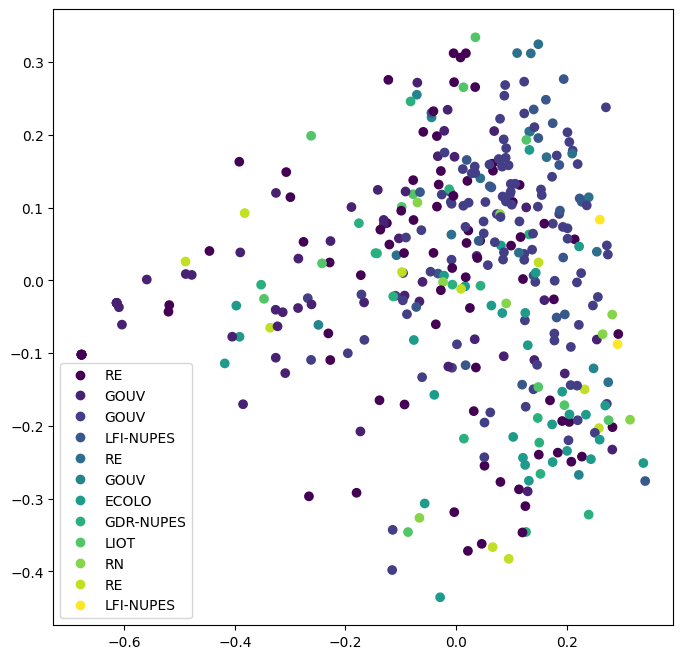

In [72]:
embeddings = np.array(qwen["embedding_speech"].tolist())

pca = PCA(n_components=2)
Y = pca.fit_transform(embeddings)

plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    Y[:,0],
    Y[:,1],
    c=groups,
)
plt.legend(handles=scatter.legend_elements()[0], labels=names)

/var/folders/ll/cm640qz57fl_rjpr2nhmfyxh0000gq/T/ipykernel_64428/3053420480.py:12: UserWarning: Mismatched number of handles and labels: len(handles) = 12 len(labels) = 362
  plt.legend(handles=scatter.legend_elements()[0], labels=names)


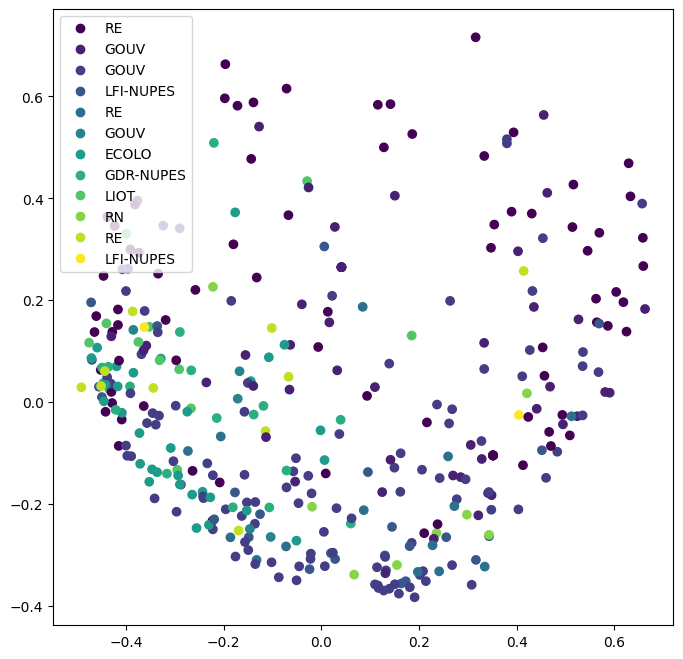

In [73]:
embeddings = np.array(custom["embedding_speech"].tolist())

pca = PCA(n_components=2)
Y = pca.fit_transform(embeddings)

plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    Y[:,0],
    Y[:,1],
    c=groups,
)
plt.legend(handles=scatter.legend_elements()[0], labels=names)

## Amendements 2025

In [8]:
qwen = pd.read_csv("./corpus/amendements_qwen_embed.csv", converters={"embedding_amendment_summary": literal_eval})
custom = pd.read_csv("./corpus/amendements_finetuned_embed.csv", converters={"embedding_amendment_summary": literal_eval})

#qwen["author_groupe"] = qwen["author_groupe"].fillna("GOUV")
#custom["author_groupe"] = custom["author_groupe"].fillna("GOUV")

In [4]:
qwen.head()

,date,debate,dossier,number,author_name,author_group,amendment_content,amendment_summary,embedding_amendment_summary
0,2025-01-20,RUANR5L17S2025IDS28939,Projet de loi d'urgence pour Mayotte,312,Sylvie Bonnet,DR,Compléter l'alinéa 4 par les mots : « et renf...,Sous amendement de précision. Il ne s'agit pas...,"[0.00543212890625, -0.09033203125, -0.00265502..."
1,2025-11-21,RUANR5L17S2026IDS29939,Projet de loi de finances pour 2026,I-3199 (Rect),David Taupiac,LIOT,I. – Rédiger ainsi l’alinéa 2 : « II. – Le se...,Les évaluations associées au présent au projet...,"[-0.0478515625, -0.0050048828125, -0.008728027..."
2,2025-11-21,RUANR5L17S2026IDS29939,Projet de loi de finances pour 2026,I-1646,Jean-Philippe Tanguy,RN,"I. – À l’alinéa 1, substituer au montant : « 4...",L’application effective de la durée légale du ...,"[-0.044189453125, -0.103515625, -0.01031494140..."
3,2025-05-22,RUANR5L17S2025IDS29396,Fin de vie,476,Charles de Courson,LIOT,"À la première phrase de l’alinéa 13, substitue...",Cet amendement propose d’étendre le délai de...,"[-0.07666015625, 0.0084228515625, -0.003295898..."
4,2025-06-14,RUANR5L17S2025IDS29559,Projet de loi de simplification de la vie écon...,2431 (Rect),Anne Stambach-Terrenoir,LFI-NFP,Dans un délai de six mois à compter de la prom...,Cet amendement du groupe LFI-NFP prévoit la re...,"[-0.0390625, -0.017822265625, -0.006103515625,..."


### Projection des embeddings

In [9]:
# == categories == #
groups, index = pd.factorize(custom["author_group"])
names = list(map(lambda a: index.tolist()[a], groups.tolist()))
names

['DR',
 'LIOT',
 'RN',
 'LIOT',
 'LFI-NFP',
 'DR',
 'UDDPLR',
 'EPR',
 'DEM',
 'ECOS',
 'LFI-NFP',
 'RN',
 'ECOS',
 'LFI-NFP',
 'DR',
 'UDR',
 'DR',
 'LIOT',
 'NI',
 'ECOS',
 'GDR',
 'EPR',
 'RN',
 'DR',
 'SOC',
 'LFI-NFP',
 'RN',
 'UDDPLR',
 'UDR',
 'LIOT',
 'UDR',
 'RN',
 'DR',
 'DR',
 'UDR',
 'EPR',
 'HOR',
 'DEM',
 'EPR',
 'GDR',
 'LFI-NFP',
 'LFI-NFP',
 'RN',
 'LIOT',
 'UDR',
 'RN',
 'DR',
 'RN',
 'RN',
 'HOR',
 'LIOT',
 'ECOS',
 'DR',
 'ECOS',
 'ECOS',
 'RN',
 'GDR',
 'DR',
 'LFI-NFP',
 'EPR',
 'RN',
 'DEM',
 'EPR',
 'DEM',
 'UDDPLR',
 'SOC',
 'LIOT',
 'LFI-NFP',
 'HOR',
 'ECOS',
 'SOC',
 'EPR',
 'LFI-NFP',
 'EPR',
 'SOC',
 'DR',
 'SOC',
 'LIOT',
 'LIOT',
 'ECOS',
 'NI',
 'LFI-NFP',
 'DR',
 'RN',
 'RN',
 'HOR',
 'DR',
 'EPR',
 'ECOS',
 'DR',
 'LFI-NFP',
 'SOC',
 'EPR',
 'DR',
 'DR',
 'UDR',
 'EPR',
 'GDR',
 'DEM',
 'LIOT',
 'ECOS',
 'DR',
 'DR',
 'DR',
 'ECOS',
 'SOC',
 'EPR',
 'RN',
 'EPR',
 'SOC',
 'LFI-NFP',
 'SOC',
 'EPR',
 'DR',
 'LFI-NFP',
 'LFI-NFP',
 'DEM',
 'HOR',
 'SOC'

/var/folders/ll/cm640qz57fl_rjpr2nhmfyxh0000gq/T/ipykernel_32235/1350243901.py:12: UserWarning: Mismatched number of handles and labels: len(handles) = 14 len(labels) = 13405
  plt.legend(handles=scatter.legend_elements()[0], labels=names)


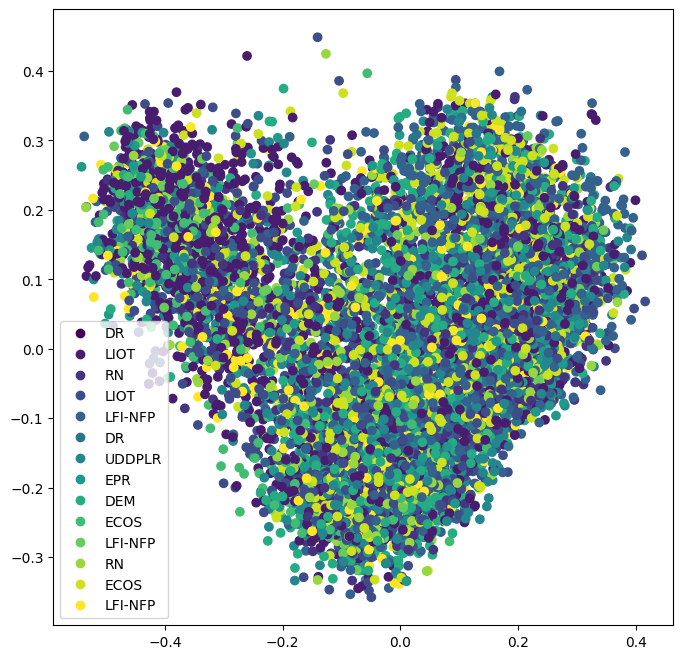

In [10]:
embeddings = np.array(qwen["embedding_amendment_summary"].tolist())

pca = PCA(n_components=2)
Y = pca.fit_transform(embeddings)

plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    Y[:,0],
    Y[:,1],
    c=groups,
)
plt.legend(handles=scatter.legend_elements()[0], labels=names)

/var/folders/ll/cm640qz57fl_rjpr2nhmfyxh0000gq/T/ipykernel_32235/2397121768.py:12: UserWarning: Mismatched number of handles and labels: len(handles) = 14 len(labels) = 13405
  plt.legend(handles=scatter.legend_elements()[0], labels=names)


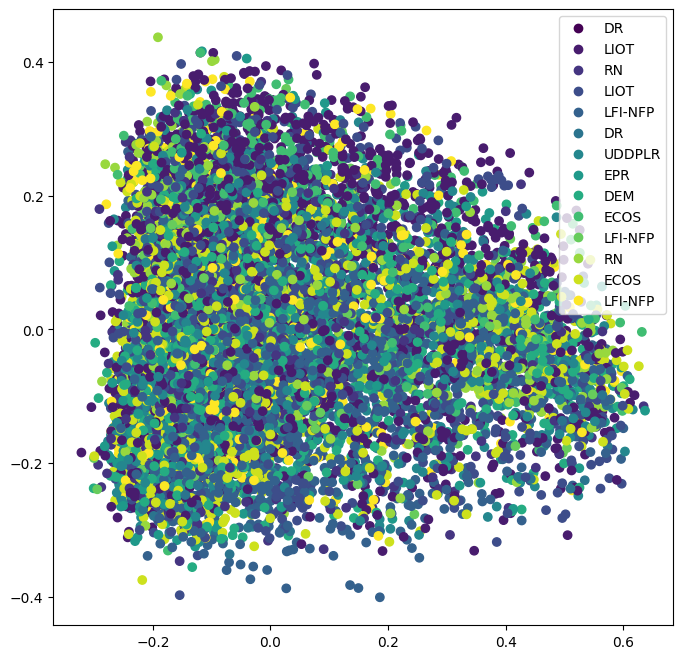

In [11]:
embeddings = np.array(custom["embedding_amendment_summary"].tolist())

pca = PCA(n_components=2)
Y = pca.fit_transform(embeddings)

plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    Y[:,0],
    Y[:,1],
    c=groups,
)
plt.legend(handles=scatter.legend_elements()[0], labels=names)